# 1. Perkenalan Dataset

Dataset yang digunakan dalam eksperimen ini adalah **Titanic Dataset**.
**Sumber Dataset**: Kaggle (https://www.kaggle.com/c/titanic/data)
**Deskripsi**: Dataset ini berisi data penumpang kapal Titanic. Tujuan klasifikasi adalah memprediksi apakah seorang penumpang selamat (`Survived` = 1) atau tidak (`Survived` = 0) berdasarkan fitur-fitur seperti kelas tiket (`Pclass`), umur (`Age`), dan tarif penumpang (`Fare`).


# 2. Import Library

Pada tahap ini, kita mengimpor pustaka (library) Python yang dibutuhkan untuk manipulasi data dan visualisasi.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


# 3. Memuat Dataset

Memuat dataset raw `titanic.csv` ke dalam DataFrame.


In [2]:
df = pd.read_csv('../dataset_raw/titanic.csv')
display(df.head())


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 4. Exploratory Data Analysis (EDA)

Melakukan eksplorasi untuk melihat informasi tipe data, mengecek *missing values*, dan melihat distribusi kelas target (Survived).


--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Jumlah Missing Values ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Ca

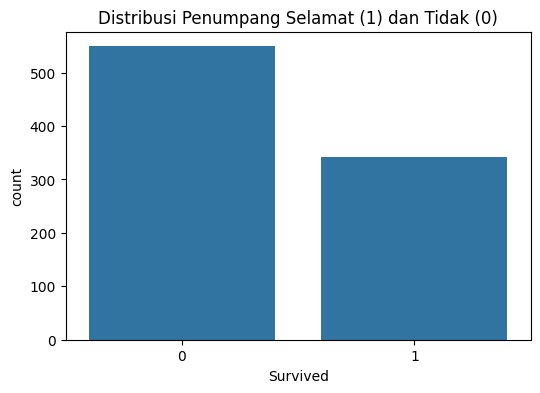

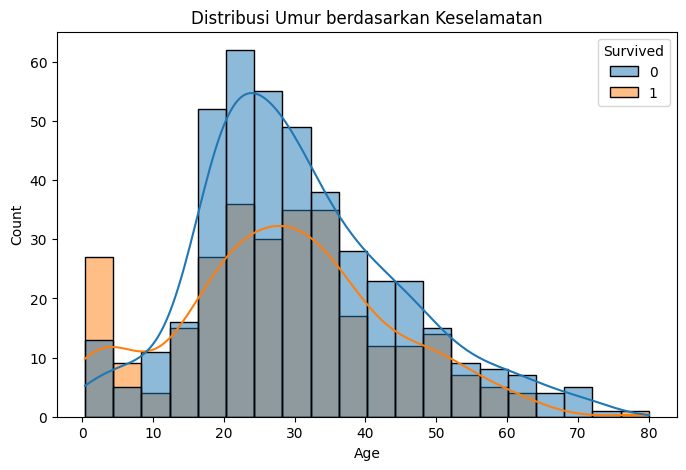

In [3]:
print("--- Info Dataset ---")
df.info()

print("\n--- Jumlah Missing Values ---")
print(df.isnull().sum())

# Plot distribusi target
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Survived')
plt.title('Distribusi Penumpang Selamat (1) dan Tidak (0)')
plt.show()

# Plot hubungan Umur dan Keselamatan
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Survived', kde=True)
plt.title('Distribusi Umur berdasarkan Keselamatan')
plt.show()


# 5. Preprocessing Data

Membersihkan data dari missing values (khususnya pada kolom `Age`) dan memilih fitur utama (`Pclass`, `Age`, `Fare`) beserta target (`Survived`).


In [4]:
# Memilih kolom yang relevan saja untuk eksperimen ini
df_selected = df[['Pclass', 'Age', 'Fare', 'Survived']].copy()

# Menghapus baris yang memiliki missing values pada kolom Age
df_clean = df_selected.dropna()

print("--- Dataset setelah dibersihkan dan difilter ---")
display(df_clean.head())


--- Dataset setelah dibersihkan dan difilter ---


,Pclass,Age,Fare,Survived
0,3,22.0,7.2500,0
1,1,38.0,71.2833,1
2,3,26.0,7.9250,1
3,1,35.0,53.1000,1
4,3,35.0,8.0500,0


In [5]:
# Menyimpan dataset bersih
os.makedirs('../Workflow-CI/MLProject/dataset_preprocessing', exist_ok=True)
df_clean.to_csv('../Workflow-CI/MLProject/dataset_preprocessing/dataset_clean.csv', index=False)

# Juga simpan ke folder preprocessing (untuk jaga-jaga kriteria)
os.makedirs('dataset_preprocessing', exist_ok=True)
df_clean.to_csv('dataset_preprocessing/dataset_clean.csv', index=False)

print("Dataset berhasil disimpan!")


Dataset berhasil disimpan!
